## Does providing $x^2$ as a feature allow a simple neural network to learn $y = x^2$ outside the bounds of its training data?

This is a follow-up to `experimenting_DL.ipynb`. That notebook showed a standard MLP with only $x$ as input **cannot** extrapolate $y = x^2$ beyond the training range.

Here we give the network **two** input features: $x$ and $x^2$, to see whether the right feature engineering solves the extrapolation problem.

### Importing data and packages

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import random
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
training_data = pd.read_csv('raw_data')
training_data = training_data[['X','Y']]

### Train test split

In [3]:
length = len(training_data)


scaler = StandardScaler()
training_data[['X','Y']] = scaler.fit_transform(training_data)

split_idx = int(length*0.8)
train_df, test_df = training_data.iloc[0:split_idx],training_data.iloc[split_idx:]

### Helper: build feature matrix with both $x$ and $x^2$

In [4]:
def make_features(x_array):
    """Given a 1-D array of x values, return a (N, 2) tensor of [x, x**2]."""
    x_t = torch.tensor(x_array, dtype=torch.float32)
    x_sq = x_t ** 2
    return torch.stack([x_t, x_sq], dim=1)

### Initializing our neural network for training

In [5]:
device = torch.device(
    "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    else "cpu"
)

X_feat = make_features(train_df['X'].to_numpy()).to(device)
Y = torch.tensor(train_df['Y'].to_numpy(), dtype=torch.float32).to(device)

loader = DataLoader(TensorDataset(X_feat, Y), batch_size=20, shuffle=True)

In [6]:
class nikkisfirstMLP(nn.Module):
    def __init__(self, d_in: int, d_hidden: int, d_out: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, d_hidden),
            nn.ReLU(),
            nn.Linear(d_hidden, d_hidden),
            nn.ReLU(),
            nn.Linear(d_hidden, d_out)
        )

    def forward(self, x):
        return self.net(x)

### Training loop

Note `d_in=2` now — the model receives both $x$ **and** $x^2$.

In [7]:
model = nikkisfirstMLP(d_in=2, d_hidden=10, d_out=1).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(5):
    model.train()
    total_loss = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb).squeeze(1)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

    print(f"epoch {epoch+1}: loss={total_loss:.4f}")

epoch 1: loss=1076.2821
epoch 2: loss=0.8568
epoch 3: loss=0.6853
epoch 4: loss=0.6758
epoch 5: loss=0.5508


### Validation set output

In [18]:
test_X_raw = test_df['X'].to_numpy()
test_Y = torch.tensor(test_df['Y'].to_numpy(), dtype=torch.float32)

test_X_feat = make_features(test_X_raw).to(device)

model.eval()
with torch.no_grad():
    preds = model(test_X_feat).squeeze(1).cpu().numpy()

output_df = pd.DataFrame({'X': test_X_raw, 'Y': preds})

MSE on validation set:  4.899267878499813e-06


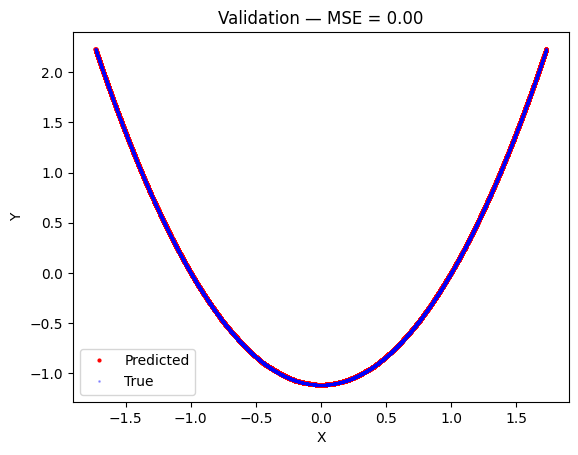

In [19]:
val_mse = criterion(torch.tensor(preds), test_Y).item()
print("MSE on validation set: ", val_mse)
plt.plot(output_df['X'], output_df['Y'], 'ro', markersize=2, label='Predicted')
plt.plot(test_X_raw, test_Y.numpy(), 'b.', markersize=2, alpha=0.3, label='True')
plt.legend()
plt.title(f'Validation — MSE = {val_mse:,.2f}')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

### How does the trained model generalize for data not in the range of generated training data from creating_data.ipynb

In [20]:
from creating_data import X_MIN, X_MAX, NOISE

BANDS = [
    (abs(X_MAX),       500),
    (500,             1_000),
    (1_000,           5_000),
    (5_000,          10_000),
    (10_000,         50_000),
    (50_000,        100_000),
]

N_PER_BAND = 2_000
band_results = []

def eval_band(lo, hi):
    """Generate OOS data in |X| ∈ [lo, hi], predict, compute & plot MSE."""
    abs_vals = np.random.uniform(lo, hi, size=N_PER_BAND)
    signs = np.random.choice([-1, 1], size=N_PER_BAND)
    xs = abs_vals * signs
    ys_true = xs ** 2

    model.eval()
    with torch.no_grad():
        x_feat = make_features(xs).to(device)
        preds = model(x_feat).squeeze(1).cpu().numpy()

    mse = float(np.mean((preds - ys_true) ** 2))
    band_results.append((lo, hi, mse))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.scatter(xs, ys_true, s=4, alpha=0.4, label="True (y=x²)")
    ax.scatter(xs, preds,   s=4, alpha=0.4, label="Predicted")
    ax.set_title(f"|X| ∈ [{lo:,.0f}, {hi:,.0f}]  —  MSE = {mse:,.2f}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.legend()
    plt.tight_layout()
    plt.show()

    return mse

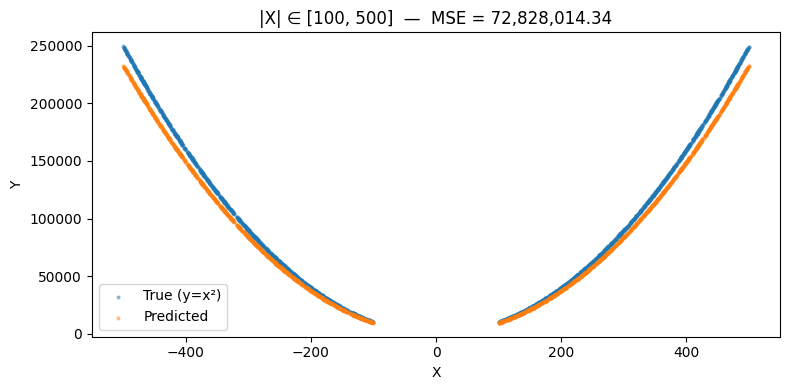

72828014.34135754

In [21]:
eval_band(*BANDS[0])

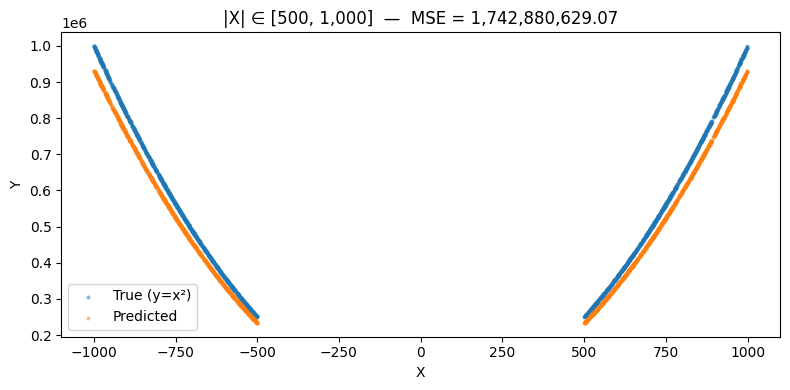

1742880629.0731313

In [22]:
eval_band(*BANDS[1])

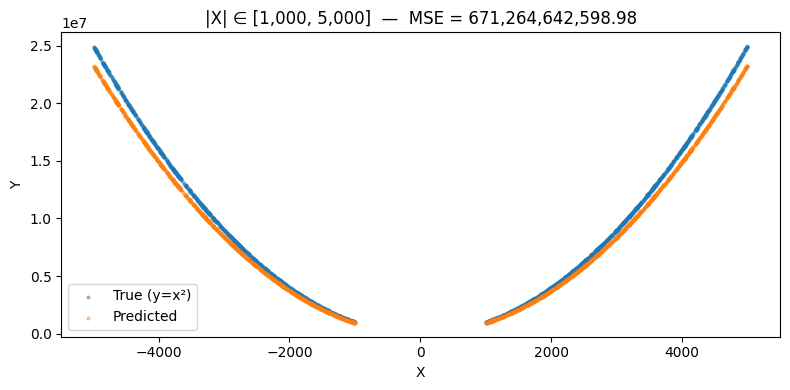

671264642598.9843

In [23]:
eval_band(*BANDS[2])

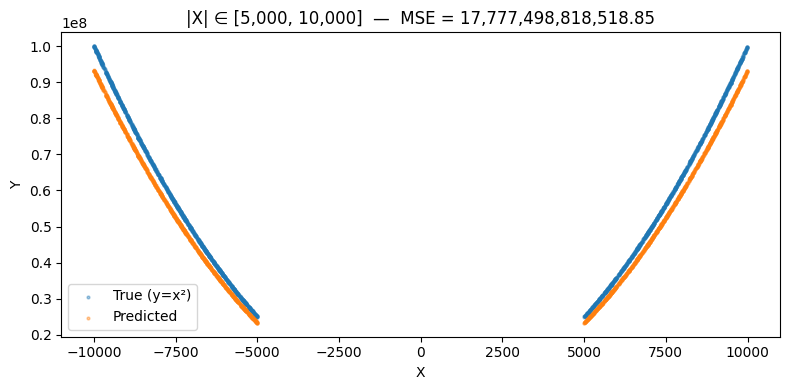

17777498818518.848

In [14]:
eval_band(*BANDS[3])

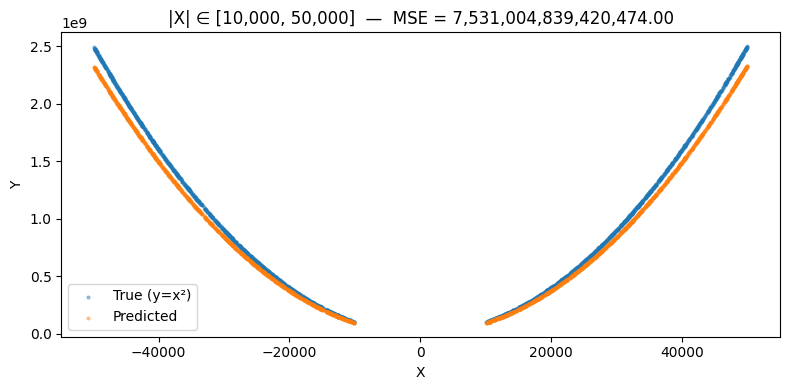

7531004839420474.0

In [24]:
eval_band(*BANDS[4])

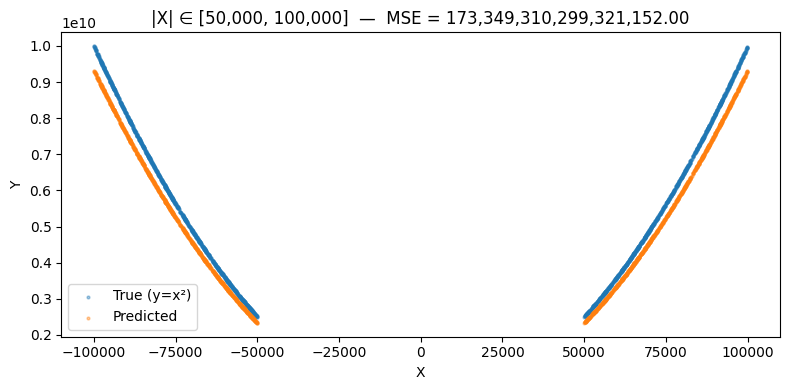

1.7334931029932115e+17

In [25]:
eval_band(*BANDS[5])

### Summary: OOS MSE by distance from training range

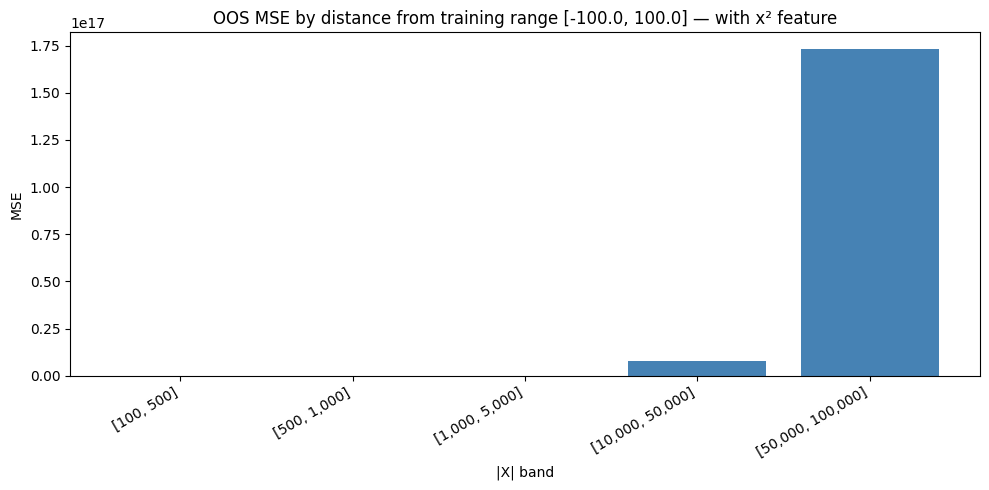

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
labels = [f"[{lo:,.0f}, {hi:,.0f}]" for lo, hi, _ in band_results]
mses   = [m for _, _, m in band_results]

ax.bar(range(len(mses)), mses, color="steelblue")
ax.set_xticks(range(len(mses)))
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylabel("MSE")
ax.set_xlabel("|X| band")
ax.set_title(f"OOS MSE by distance from training range [{X_MIN}, {X_MAX}] — with x² feature")
ax.ticklabel_format(axis="y", style="scientific", scilimits=(0, 0))
plt.tight_layout()
plt.show()